Gas-like Pressure: 29224103498068.7891 kcal/mol/Å²
Liquid-like Pressure: 584191269401412.1250 kcal/mol/Å²


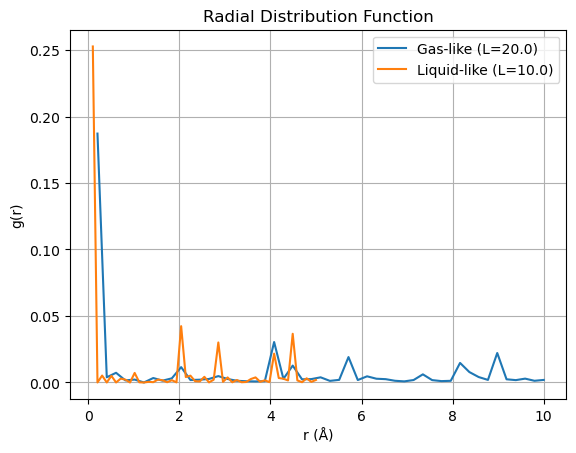

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
L_gas = 20.0
L_liquid = 10.0
steps = 2000
dt = 0.005
m = 1.0
sigma = 3.8
epsilon = 0.4
kB = 0.001987
T = 300.0

def pbc(x, L):
    return x % L

def forces(coords, L):
    F = np.zeros_like(coords)
    E = 0.0
    virial = 0.0
    for i in range(N):
        for j in range(i+1, N):
            dx = coords[i,0] - coords[j,0]
            dy = coords[i,1] - coords[j,1]
            dx -= L * np.round(dx / L)
            dy -= L * np.round(dy / L)
            r = np.sqrt(dx*dx + dy*dy)
            if r > 0 and r < 2.5*sigma:
                sr6 = (sigma/r)**6
                sr12 = sr6*sr6
                E += 4*epsilon*(sr12 - sr6)
                f = 24*epsilon*(2*sr12 - sr6)/r**2
                F[i,0] += f*dx/r
                F[i,1] += f*dy/r
                F[j,0] -= f*dx/r
                F[j,1] -= f*dy/r
                virial += dx * f * dx/r + dy * f * dy/r
    return F, E, virial

def radial_distribution(coords, L, r_max, bins):
    r = np.linspace(0, r_max, bins)
    g_r = np.zeros(bins-1)
    rho = N / (L*L)
    for i in range(N):
        for j in range(i+1, N):
            dx = coords[i,0] - coords[j,0]
            dy = coords[i,1] - coords[j,1]
            dx -= L * np.round(dx / L)
            dy -= L * np.round(dy / L)
            r_ij = np.sqrt(dx*dx + dy*dy)
            if r_ij < r_max:
                bin_idx = int((r_ij / r_max) * (bins-1))
                g_r[bin_idx] += 2
    g_r = g_r / (2 * np.pi * r[1:bins] * rho * N * (r_max/bins) * steps/10)
    return r[1:bins], g_r

for L, label in [(L_gas, "Gas-like"), (L_liquid, "Liquid-like")]:
    coords = np.random.uniform(0, L, (N, 2))
    velocities = np.random.normal(0, np.sqrt(kB*T/m), (N, 2))
    F, E, virial = forces(coords, L)
    for step in range(steps):
        coords = pbc(coords + velocities*dt + 0.5*F/m*dt**2, L)
        F_new, E, virial = forces(coords, L)
        velocities = velocities + 0.5*(F + F_new)/m*dt
        F = F_new
        if step % 10 == 0:
            r, g_r = radial_distribution(coords, L, L/2, 50)
    pressure = N*kB*T/(L*L) + virial/(2*L*L)
    print(f"{label} Pressure: {pressure:.4f} kcal/mol/Å²")
    plt.plot(r, g_r, label=f"{label} (L={L})")

plt.xlabel("r (Å)")
plt.ylabel("g(r)")
plt.title("Radial Distribution Function")
plt.legend()
plt.grid(True)
plt.show()